In [1]:
import os

print(os.getcwd())
print()

for f in os.listdir():
    print(f)

/content

.config
sample_data


In [2]:
from google.colab import files

uploaded = files.upload()

Saving Europa_Horizons_Jovicentric_Vector_2026_1h_RAW.csv to Europa_Horizons_Jovicentric_Vector_2026_1h_RAW.csv


In [3]:
# ============================================================
# GVH Europa Real Data Pipeline 0.1
# Étape 1 — Import et extraction des données Horizons
# ============================================================

import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Chemin du fichier
# ------------------------------------------------------------

FICHIER_RAW = (
    "/content/"
    "Europa_Horizons_Jovicentric_Vector_2026_1h_RAW.csv"
)


# ------------------------------------------------------------
# 2. Lecture du fichier Horizons complet
# ------------------------------------------------------------

with open(
    FICHIER_RAW,
    "r",
    encoding="utf-8",
    errors="replace"
) as fichier:

    lignes = fichier.readlines()


# ------------------------------------------------------------
# 3. Repérage de la zone de données
# ------------------------------------------------------------

indice_debut = next(
    i for i, ligne in enumerate(lignes)
    if "$$SOE" in ligne
)

indice_fin = next(
    i for i, ligne in enumerate(lignes)
    if "$$EOE" in ligne
)

lignes_donnees = lignes[
    indice_debut + 1 : indice_fin
]


# ------------------------------------------------------------
# 4. Reconstruction d'un CSV propre
# ------------------------------------------------------------

texte_donnees = "".join(lignes_donnees)

colonnes = [
    "JDTDB",
    "Date_TDB",
    "X",
    "Y",
    "Z",
    "VX",
    "VY",
    "VZ",
    "LT",
    "RG",
    "RR",
    "Colonne_vide",
]

europa = pd.read_csv(
    io.StringIO(texte_donnees),
    header=None,
    names=colonnes,
    skipinitialspace=True
)


# ------------------------------------------------------------
# 5. Suppression de la dernière colonne vide
# ------------------------------------------------------------

europa = europa.drop(
    columns=["Colonne_vide"],
    errors="ignore"
)


# ------------------------------------------------------------
# 6. Nettoyage de la date
# ------------------------------------------------------------

europa["Date_TDB"] = (
    europa["Date_TDB"]
    .astype(str)
    .str.strip()
    .str.replace(
        r"^A\.D\.\s+",
        "",
        regex=True
    )
)

europa["Date"] = pd.to_datetime(
    europa["Date_TDB"],
    format="%Y-%b-%d %H:%M:%S.%f",
    errors="raise"
)


# ------------------------------------------------------------
# 7. Conversion numérique
# ------------------------------------------------------------

colonnes_numeriques = [
    "JDTDB",
    "X",
    "Y",
    "Z",
    "VX",
    "VY",
    "VZ",
    "LT",
    "RG",
    "RR",
]

for colonne in colonnes_numeriques:
    europa[colonne] = pd.to_numeric(
        europa[colonne],
        errors="raise"
    )


# ------------------------------------------------------------
# 8. Ordre final des colonnes
# ------------------------------------------------------------

europa = europa[
    [
        "Date",
        "JDTDB",
        "X",
        "Y",
        "Z",
        "VX",
        "VY",
        "VZ",
        "LT",
        "RG",
        "RR",
    ]
].copy()


# ------------------------------------------------------------
# 9. Affichage initial
# ------------------------------------------------------------

print("=" * 90)
print("IMPORT HORIZONS — EUROPA")
print("=" * 90)

print(f"Début de la zone de données : ligne {indice_debut + 1}")
print(f"Fin de la zone de données   : ligne {indice_fin + 1}")
print(f"Nombre d'observations       : {len(europa)}")

display(europa.head())
display(europa.tail())

IMPORT HORIZONS — EUROPA
Début de la zone de données : ligne 37
Fin de la zone de données   : ligne 8799
Nombre d'observations       : 8761


,Date,JDTDB,X,Y,Z,VX,VY,VZ,LT,RG,RR
0,2026-01-01 00:00:00,2.461042e+06,82550.144901,-669527.246784,-19090.319605,13.546146,1.765538,0.339831,2.251115,674867.172792,-0.104208
1,2026-01-01 01:00:00,2.461042e+06,131052.128721,-661387.832506,-17817.011162,13.387344,2.754623,0.367255,2.249830,674482.002218,-0.109681
2,2026-01-01 02:00:00,2.461042e+06,178852.631650,-649709.602637,-16448.385518,13.156564,3.730675,0.392760,2.248483,674078.171278,-0.114571
3,2026-01-01 03:00:00,2.461042e+06,225694.161791,-634548.864844,-14991.610581,12.854773,4.688485,0.416204,2.247081,673657.824811,-0.118852
4,2026-01-01 04:00:00,2.461042e+06,271323.379039,-615980.583380,-13454.347275,12.483311,5.622902,0.437455,2.245631,673223.198186,-0.122500


,Date,JDTDB,X,Y,Z,VX,VY,VZ,LT,RG,RR
8756,2026-12-31 20:00:00,2.461406e+06,-665552.189005,-40352.525364,-14452.426662,0.750267,-13.800178,-0.396924,2.224642,666930.967364,0.094862
8757,2026-12-31 21:00:00,2.461406e+06,-661013.325953,-89875.932215,-15840.070736,1.769894,-13.700169,-0.373640,2.225818,667283.454103,0.100873
8758,2026-12-31 22:00:00,2.461406e+06,-652822.659942,-138903.172765,-17140.208230,2.778103,-13.524700,-0.348333,2.227063,667656.576000,0.106321
8759,2026-12-31 23:00:00,2.461406e+06,-641031.420833,-187164.686629,-18345.815531,3.769288,-13.275006,-0.321149,2.228369,668048.255266,0.111178
8760,2027-01-01 00:00:00,2.461406e+06,-625710.790670,-234396.108971,-19450.421274,4.737977,-12.952737,-0.292248,2.229730,668456.317457,0.115419


In [4]:
# ============================================================
# Étape 2 — Audit structurel et temporel
# ============================================================

# ------------------------------------------------------------
# 1. Dimensions
# ------------------------------------------------------------

n_observations = len(europa)

n_doublons_dates = int(
    europa["Date"].duplicated().sum()
)

n_doublons_complets = int(
    europa.duplicated().sum()
)

n_valeurs_manquantes = int(
    europa.isna().sum().sum()
)


# ------------------------------------------------------------
# 2. Pas temporel
# ------------------------------------------------------------

delta_t = europa["Date"].diff().dropna()

delta_t_heures = (
    delta_t.dt.total_seconds() / 3600.0
)

pas_median_heures = float(
    delta_t_heures.median()
)

pas_min_heures = float(
    delta_t_heures.min()
)

pas_max_heures = float(
    delta_t_heures.max()
)

pas_irreguliers = int(
    (~np.isclose(
        delta_t_heures,
        1.0,
        rtol=0.0,
        atol=1e-9
    )).sum()
)


# ------------------------------------------------------------
# 3. Contrôle des dates attendues
# ------------------------------------------------------------

date_debut_attendue = pd.Timestamp(
    "2026-01-01 00:00:00"
)

date_fin_attendue = pd.Timestamp(
    "2027-01-01 00:00:00"
)

controle_debut = (
    europa["Date"].iloc[0]
    == date_debut_attendue
)

controle_fin = (
    europa["Date"].iloc[-1]
    == date_fin_attendue
)

controle_nombre = (
    n_observations == 8761
)


# ------------------------------------------------------------
# 4. Tableau d'audit
# ------------------------------------------------------------

audit_europa = pd.DataFrame({
    "Controle": [
        "Nombre d'observations",
        "Date initiale",
        "Date finale",
        "Pas médian (h)",
        "Pas minimal (h)",
        "Pas maximal (h)",
        "Pas irréguliers",
        "Doublons de dates",
        "Doublons complets",
        "Valeurs manquantes",
    ],
    "Valeur": [
        n_observations,
        europa["Date"].iloc[0],
        europa["Date"].iloc[-1],
        pas_median_heures,
        pas_min_heures,
        pas_max_heures,
        pas_irreguliers,
        n_doublons_dates,
        n_doublons_complets,
        n_valeurs_manquantes,
    ],
    "Validation": [
        controle_nombre,
        controle_debut,
        controle_fin,
        np.isclose(pas_median_heures, 1.0),
        np.isclose(pas_min_heures, 1.0),
        np.isclose(pas_max_heures, 1.0),
        pas_irreguliers == 0,
        n_doublons_dates == 0,
        n_doublons_complets == 0,
        n_valeurs_manquantes == 0,
    ],
})


print("=" * 90)
print("AUDIT STRUCTUREL ET TEMPOREL — EUROPA")
print("=" * 90)

display(audit_europa)

if audit_europa["Validation"].all():
    print("\nTous les contrôles ont réussi.")
else:
    print("\nAttention : au moins un contrôle a échoué.")

AUDIT STRUCTUREL ET TEMPOREL — EUROPA


,Controle,Valeur,Validation
0,Nombre d'observations,8761,True
1,Date initiale,2026-01-01 00:00:00,True
2,Date finale,2027-01-01 00:00:00,True
3,Pas médian (h),1.0,True
4,Pas minimal (h),1.0,True
5,Pas maximal (h),1.0,True
6,Pas irréguliers,0,True
7,Doublons de dates,0,True
8,Doublons complets,0,True
9,Valeurs manquantes,0,True



Tous les contrôles ont réussi.


In [5]:
# ============================================================
# Étape 3 — Vecteurs de transition et observable D_T
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Matrice des positions
# ------------------------------------------------------------

R = europa[
    ["X", "Y", "Z"]
].to_numpy(dtype=float)


# ------------------------------------------------------------
# 2. Vecteurs de transition
# ------------------------------------------------------------

delta_R = np.diff(
    R,
    axis=0
)


# ------------------------------------------------------------
# 3. Norme des transitions
# ------------------------------------------------------------

D_T = np.linalg.norm(
    delta_R,
    axis=1
)


# ------------------------------------------------------------
# 4. Dates associées aux transitions
# ------------------------------------------------------------

dates_D_T = europa[
    "Date"
].iloc[1:].reset_index(drop=True)


# ------------------------------------------------------------
# 5. Statistiques principales
# ------------------------------------------------------------

D_T_mean = float(
    np.mean(D_T)
)

D_T_std = float(
    np.std(D_T, ddof=0)
)

D_T_min = float(
    np.min(D_T)
)

D_T_median = float(
    np.median(D_T)
)

D_T_max = float(
    np.max(D_T)
)

S_T_norm = float(
    D_T_std / D_T_mean
)


# ------------------------------------------------------------
# 6. Tableau des transitions
# ------------------------------------------------------------

transitions_europa = pd.DataFrame({
    "Date": dates_D_T,
    "dX_km": delta_R[:, 0],
    "dY_km": delta_R[:, 1],
    "dZ_km": delta_R[:, 2],
    "D_T_km": D_T,
})


# ------------------------------------------------------------
# 7. Résumé
# ------------------------------------------------------------

resume_D_T = pd.DataFrame({
    "Observable": [
        "N_observations",
        "N_transitions",
        "D_T_mean_km",
        "D_T_std_km",
        "S_T_norm",
        "D_T_min_km",
        "D_T_median_km",
        "D_T_max_km",
    ],
    "Valeur": [
        len(R),
        len(D_T),
        D_T_mean,
        D_T_std,
        S_T_norm,
        D_T_min,
        D_T_median,
        D_T_max,
    ],
})


# ------------------------------------------------------------
# 8. Contrôles
# ------------------------------------------------------------

controle_D_T = pd.DataFrame({
    "Controle": [
        "Nombre de positions",
        "Nombre de transitions",
        "Valeurs D_T finies",
        "Transitions strictement positives",
        "Dispersion normalisée finie",
    ],
    "Valeur": [
        len(R),
        len(D_T),
        int(np.isfinite(D_T).sum()),
        int((D_T > 0).sum()),
        S_T_norm,
    ],
    "Validation": [
        len(R) == 8761,
        len(D_T) == 8760,
        np.isfinite(D_T).all(),
        (D_T > 0).all(),
        np.isfinite(S_T_norm),
    ],
})


print("=" * 90)
print("TRANSITIONS GVH — EUROPA")
print("=" * 90)

display(resume_D_T)

print("\nContrôles :")
display(controle_D_T)

print("\nPremières transitions :")
display(transitions_europa.head())

if controle_D_T["Validation"].all():
    print("\nCalcul de D_T validé.")
else:
    print("\nAttention : au moins un contrôle a échoué.")

TRANSITIONS GVH — EUROPA


,Observable,Valeur
0,N_observations,8761.000000
1,N_transitions,8760.000000
2,D_T_mean_km,49460.672996
3,D_T_std_km,326.575789
4,S_T_norm,0.006603
5,D_T_min_km,48991.003156
6,D_T_median_km,49459.676272
7,D_T_max_km,49933.483474



Contrôles :


,Controle,Valeur,Validation
0,Nombre de positions,8761.000000,True
1,Nombre de transitions,8760.000000,True
2,Valeurs D_T finies,8760.000000,True
3,Transitions strictement positives,8760.000000,True
4,Dispersion normalisée finie,0.006603,True



Premières transitions :


,Date,dX_km,dY_km,dZ_km,D_T_km
0,2026-01-01 01:00:00,48501.983819,8139.414278,1273.308443,49196.684986
1,2026-01-01 02:00:00,47800.502929,11678.229869,1368.625644,49225.422998
2,2026-01-01 03:00:00,46841.530141,15160.737794,1456.774937,49255.447512
3,2026-01-01 04:00:00,45629.217248,18568.281464,1537.263307,49286.607934
4,2026-01-01 05:00:00,44169.054134,21882.446966,1609.633408,49318.736277



Calcul de D_T validé.


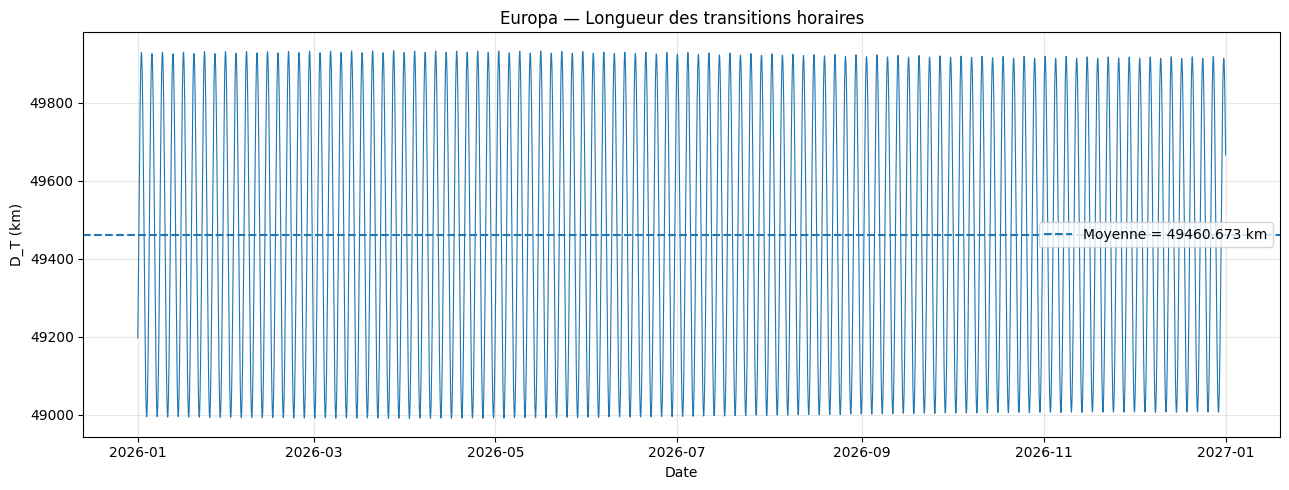

In [6]:
# ============================================================
# Étape 3B — Visualisation de D_T
# ============================================================

plt.figure(figsize=(13, 5))

plt.plot(
    dates_D_T,
    D_T,
    linewidth=0.8
)

plt.axhline(
    D_T_mean,
    linestyle="--",
    label=f"Moyenne = {D_T_mean:.3f} km"
)

plt.xlabel("Date")
plt.ylabel("D_T (km)")
plt.title("Europa — Longueur des transitions horaires")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# Étape 4 — Seuil critique et supercriticité GVH
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Quantile critique
# ------------------------------------------------------------

Q_CRITIQUE = 0.95

D_c = float(
    np.quantile(
        D_T,
        Q_CRITIQUE
    )
)


# ------------------------------------------------------------
# 2. Masque supercritique
# ------------------------------------------------------------

masque_supercritique = (
    D_T > D_c
)

D_T_super = D_T[
    masque_supercritique
]


# ------------------------------------------------------------
# 3. Statistiques supercritiques
# ------------------------------------------------------------

n_super = int(
    masque_supercritique.sum()
)

R_super = float(
    masque_supercritique.mean()
)

D_T_super_min = float(
    np.min(D_T_super)
)

D_T_super_mean = float(
    np.mean(D_T_super)
)

D_T_super_max = float(
    np.max(D_T_super)
)


# ------------------------------------------------------------
# 4. Tableau détaillé
# ------------------------------------------------------------

supercriticite_europa = transitions_europa.copy()

supercriticite_europa[
    "Supercritique"
] = masque_supercritique

supercriticite_europa[
    "Exces_sur_Dc_km"
] = D_T - D_c


# ------------------------------------------------------------
# 5. Résumé
# ------------------------------------------------------------

observables_supercriticite = pd.DataFrame({
    "Observable": [
        "Quantile_critique",
        "D_c_km",
        "N_supercritique",
        "R_super",
        "D_T_super_min_km",
        "D_T_super_mean_km",
        "D_T_super_max_km",
    ],
    "Valeur": [
        Q_CRITIQUE,
        D_c,
        n_super,
        R_super,
        D_T_super_min,
        D_T_super_mean,
        D_T_super_max,
    ],
})


# ------------------------------------------------------------
# 6. Contrôles
# ------------------------------------------------------------

controle_supercriticite = pd.DataFrame({
    "Controle": [
        "D_c compris dans l'étendue D_T",
        "Nombre supercritique positif",
        "R_super compris entre 0 et 1",
        "R_super proche de 5 %",
        "Toutes les valeurs supercritiques dépassent D_c",
    ],
    "Valeur": [
        D_c,
        n_super,
        R_super,
        abs(R_super - 0.05),
        bool(
            np.all(
                D_T_super > D_c
            )
        ),
    ],
    "Validation": [
        D_T_min <= D_c <= D_T_max,
        n_super > 0,
        0.0 <= R_super <= 1.0,
        abs(R_super - 0.05) <= 1.0 / len(D_T),
        np.all(D_T_super > D_c),
    ],
})


print("=" * 90)
print("SUPERCRITICITÉ GVH — EUROPA")
print("=" * 90)

display(observables_supercriticite)

print("\nContrôles :")
display(controle_supercriticite)

print("\nPremières transitions supercritiques :")
display(
    supercriticite_europa[
        supercriticite_europa["Supercritique"]
    ].head()
)

if controle_supercriticite["Validation"].all():
    print("\nÉtape de supercriticité validée.")
else:
    print("\nAttention : au moins un contrôle a échoué.")

SUPERCRITICITÉ GVH — EUROPA


,Observable,Valeur
0,Quantile_critique,0.950000
1,D_c_km,49917.132585
2,N_supercritique,438.000000
3,R_super,0.050000
4,D_T_super_min_km,49917.159035
5,D_T_super_mean_km,49924.137750
6,D_T_super_max_km,49933.483474



Contrôles :


,Controle,Valeur,Validation
0,D_c compris dans l'étendue D_T,49917.132585,True
1,Nombre supercritique positif,438,True
2,R_super compris entre 0 et 1,0.05,True
3,R_super proche de 5 %,0.0,True
4,Toutes les valeurs supercritiques dépassent D_c,True,True



Premières transitions supercritiques :


,Date,dX_km,dY_km,dZ_km,D_T_km,Supercritique,Exces_sur_Dc_km
27,2026-01-02 04:00:00,-27875.715213,41408.660765,701.575065,49922.188379,True,5.055795
28,2026-01-02 05:00:00,-30878.739244,39228.194553,570.602239,49926.679963,True,9.547378
29,2026-01-02 06:00:00,-33709.767560,36828.142078,436.419649,49928.458217,True,11.325632
30,2026-01-02 07:00:00,-36352.495820,34222.247213,299.797706,49927.507802,True,10.375217
31,2026-01-02 08:00:00,-38791.762435,31425.505758,161.521653,49923.835331,True,6.702747



Étape de supercriticité validée.


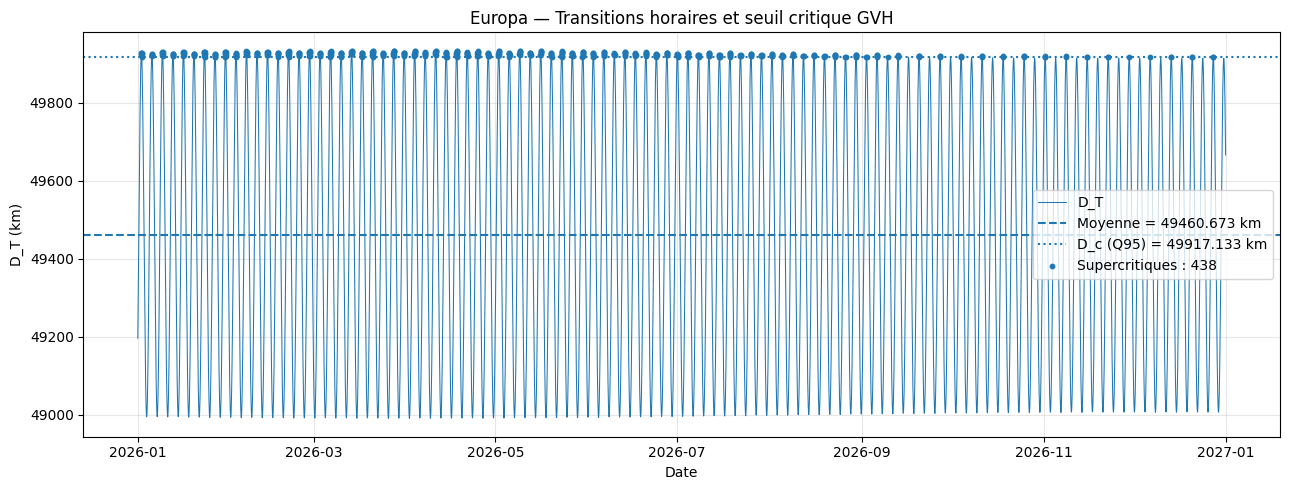

In [8]:
# ============================================================
# Étape 4B — Visualisation du seuil critique
# ============================================================

plt.figure(figsize=(13, 5))

plt.plot(
    dates_D_T,
    D_T,
    linewidth=0.75,
    label="D_T"
)

plt.axhline(
    D_T_mean,
    linestyle="--",
    label=f"Moyenne = {D_T_mean:.3f} km"
)

plt.axhline(
    D_c,
    linestyle=":",
    label=f"D_c (Q95) = {D_c:.3f} km"
)

plt.scatter(
    dates_D_T[masque_supercritique],
    D_T_super,
    s=10,
    label=f"Supercritiques : {n_super}"
)

plt.xlabel("Date")
plt.ylabel("D_T (km)")
plt.title(
    "Europa — Transitions horaires et seuil critique GVH"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# Étape 5 — Fonction de survie empirique de D_T
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Normalisation des transitions
# ------------------------------------------------------------

D_T_max = float(np.max(D_T))

u = D_T / D_T_max

u_sorted = np.sort(u)


# ------------------------------------------------------------
# 2. Fonction de survie empirique
# ------------------------------------------------------------

n_u = len(u_sorted)

R_survie = (
    n_u - np.arange(n_u)
) / n_u


# ------------------------------------------------------------
# 3. Tableau de survie
# ------------------------------------------------------------

survie_europa = pd.DataFrame({
    "u": u_sorted,
    "R_survie": R_survie,
})


# ------------------------------------------------------------
# 4. Valeur normalisée du seuil critique
# ------------------------------------------------------------

u_c = float(D_c / D_T_max)

R_super_direct = float(
    np.mean(u > u_c)
)


# ------------------------------------------------------------
# 5. Résumé
# ------------------------------------------------------------

observables_survie_europa = pd.DataFrame({
    "Observable": [
        "D_T_max_km",
        "u_min",
        "u_mean",
        "u_median",
        "u_max",
        "u_c",
        "R_super_quantile",
        "R_super_direct",
    ],
    "Valeur": [
        D_T_max,
        float(np.min(u)),
        float(np.mean(u)),
        float(np.median(u)),
        float(np.max(u)),
        u_c,
        R_super,
        R_super_direct,
    ],
})


# ------------------------------------------------------------
# 6. Contrôles
# ------------------------------------------------------------

controle_survie = pd.DataFrame({
    "Controle": [
        "u dans [0,1]",
        "u trié croissant",
        "R_survie décroissante",
        "R_survie initiale égale à 1",
        "R_super direct cohérent",
    ],
    "Valeur": [
        bool(np.all((u >= 0.0) & (u <= 1.0))),
        bool(np.all(np.diff(u_sorted) >= 0.0)),
        bool(np.all(np.diff(R_survie) <= 0.0)),
        float(R_survie[0]),
        abs(R_super_direct - R_super),
    ],
    "Validation": [
        np.all((u >= 0.0) & (u <= 1.0)),
        np.all(np.diff(u_sorted) >= 0.0),
        np.all(np.diff(R_survie) <= 0.0),
        np.isclose(R_survie[0], 1.0),
        np.isclose(R_super_direct, R_super),
    ],
})


print("=" * 90)
print("FONCTION DE SURVIE GVH — EUROPA")
print("=" * 90)

display(observables_survie_europa)

print("\nContrôles :")
display(controle_survie)

display(survie_europa.head())
display(survie_europa.tail())

if controle_survie["Validation"].all():
    print("\nFonction de survie validée.")
else:
    print("\nAttention : au moins un contrôle a échoué.")

FONCTION DE SURVIE GVH — EUROPA


,Observable,Valeur
0,D_T_max_km,49933.483474
1,u_min,0.981125
2,u_mean,0.990531
3,u_median,0.990511
4,u_max,1.000000
5,u_c,0.999673
6,R_super_quantile,0.050000
7,R_super_direct,0.050000



Contrôles :


,Controle,Valeur,Validation
0,"u dans [0,1]",True,True
1,u trié croissant,True,True
2,R_survie décroissante,True,True
3,R_survie initiale égale à 1,1.0,True
4,R_super direct cohérent,0.0,True


,u,R_survie
0,0.981125,1.000000
1,0.981126,0.999886
2,0.981129,0.999772
3,0.981130,0.999658
4,0.981131,0.999543


,u,R_survie
8755,0.999984,0.000571
8756,0.999987,0.000457
8757,0.999988,0.000342
8758,0.999991,0.000228
8759,1.000000,0.000114



Fonction de survie validée.


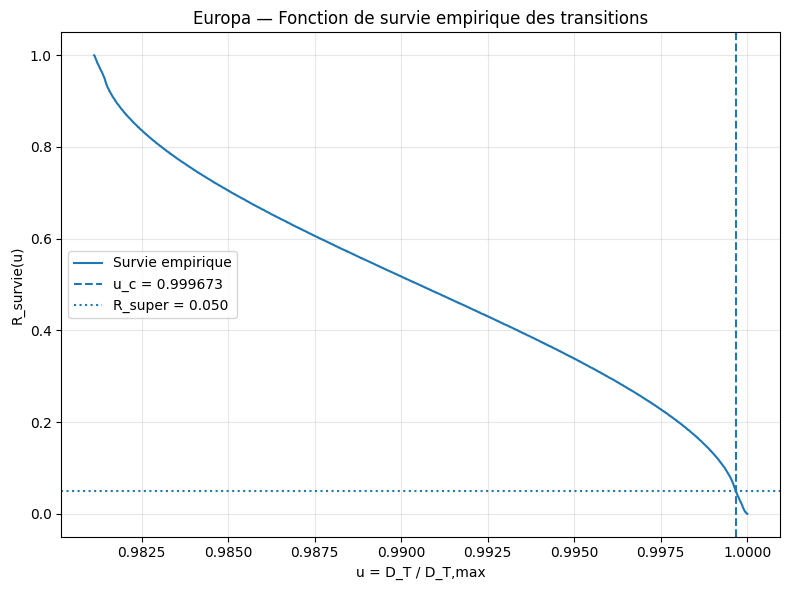

In [10]:
# ============================================================
# Étape 5B — Graphique de la fonction de survie
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    u_sorted,
    R_survie,
    linewidth=1.5,
    label="Survie empirique"
)

plt.axvline(
    u_c,
    linestyle="--",
    label=f"u_c = {u_c:.6f}"
)

plt.axhline(
    R_super,
    linestyle=":",
    label=f"R_super = {R_super:.3f}"
)

plt.xlabel("u = D_T / D_T,max")
plt.ylabel("R_survie(u)")
plt.title("Europa — Fonction de survie empirique des transitions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# Étape 6 — Ajustements de la fonction de survie
# ============================================================

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit


# ------------------------------------------------------------
# 1. Modèles
# ------------------------------------------------------------

def modele_exponentiel(u, A_H, B_H):
    return A_H * np.exp(-B_H * u)


def modele_weibull(u, lam, k):
    return np.exp(
        -np.power(
            u / lam,
            k
        )
    )


def modele_logistique(u, u0, k):
    argument = np.clip(
        k * (u - u0),
        -700,
        700
    )

    return 1.0 / (
        1.0 + np.exp(argument)
    )


# ------------------------------------------------------------
# 2. Données d'ajustement
# ------------------------------------------------------------

u_fit = np.asarray(
    u_sorted,
    dtype=float
)

R_fit = np.asarray(
    R_survie,
    dtype=float
)

n_fit = len(u_fit)


# ------------------------------------------------------------
# 3. Fonction de métriques
# ------------------------------------------------------------

def calculer_metriques(y_obs, y_pred, n_parametres):

    residus = y_obs - y_pred

    rss = float(
        np.sum(residus ** 2)
    )

    rmse = float(
        np.sqrt(
            np.mean(residus ** 2)
        )
    )

    moyenne_obs = float(
        np.mean(y_obs)
    )

    tss = float(
        np.sum(
            (y_obs - moyenne_obs) ** 2
        )
    )

    if tss > 0:
        r2 = float(
            1.0 - rss / tss
        )
    else:
        r2 = np.nan

    rss_securise = max(
        rss,
        np.finfo(float).tiny
    )

    aic = float(
        len(y_obs)
        * np.log(
            rss_securise / len(y_obs)
        )
        + 2 * n_parametres
    )

    bic = float(
        len(y_obs)
        * np.log(
            rss_securise / len(y_obs)
        )
        + n_parametres
        * np.log(len(y_obs))
    )

    return {
        "RSS": rss,
        "RMSE": rmse,
        "R2": r2,
        "AIC": aic,
        "BIC": bic,
    }


# ------------------------------------------------------------
# 4. Ajustement exponentiel
# ------------------------------------------------------------

popt_exp, pcov_exp = curve_fit(
    modele_exponentiel,
    u_fit,
    R_fit,
    p0=[
        1.0,
        1.0
    ],
    bounds=(
        [
            0.0,
            0.0
        ],
        [
            np.inf,
            np.inf
        ]
    ),
    maxfev=200000
)

A_H_exp = float(
    popt_exp[0]
)

B_H_exp = float(
    popt_exp[1]
)

R_pred_exp = modele_exponentiel(
    u_fit,
    A_H_exp,
    B_H_exp
)

metriques_exp = calculer_metriques(
    R_fit,
    R_pred_exp,
    n_parametres=2
)


# ------------------------------------------------------------
# 5. Ajustement Weibull
# ------------------------------------------------------------

popt_weibull, pcov_weibull = curve_fit(
    modele_weibull,
    u_fit,
    R_fit,
    p0=[
        0.99,
        100.0
    ],
    bounds=(
        [
            1e-8,
            1e-8
        ],
        [
            10.0,
            1e6
        ]
    ),
    maxfev=300000
)

lambda_weibull = float(
    popt_weibull[0]
)

k_weibull = float(
    popt_weibull[1]
)

R_pred_weibull = modele_weibull(
    u_fit,
    lambda_weibull,
    k_weibull
)

metriques_weibull = calculer_metriques(
    R_fit,
    R_pred_weibull,
    n_parametres=2
)


# ------------------------------------------------------------
# 6. Ajustement logistique
# ------------------------------------------------------------

popt_logistique, pcov_logistique = curve_fit(
    modele_logistique,
    u_fit,
    R_fit,
    p0=[
        float(np.median(u_fit)),
        300.0
    ],
    bounds=(
        [
            float(np.min(u_fit) - 0.1),
            1e-8
        ],
        [
            float(np.max(u_fit) + 0.1),
            1e6
        ]
    ),
    maxfev=300000
)

u0_logistique = float(
    popt_logistique[0]
)

k_logistique = float(
    popt_logistique[1]
)

R_pred_logistique = modele_logistique(
    u_fit,
    u0_logistique,
    k_logistique
)

metriques_logistique = calculer_metriques(
    R_fit,
    R_pred_logistique,
    n_parametres=2
)


# ------------------------------------------------------------
# 7. Tableau comparatif
# ------------------------------------------------------------

comparaison_modeles_survie = pd.DataFrame({
    "Modele": [
        "Exponentiel",
        "Weibull",
        "Logistique",
    ],
    "Parametre_1_nom": [
        "A_H",
        "lambda",
        "u0",
    ],
    "Parametre_1": [
        A_H_exp,
        lambda_weibull,
        u0_logistique,
    ],
    "Parametre_2_nom": [
        "B_H",
        "k",
        "k",
    ],
    "Parametre_2": [
        B_H_exp,
        k_weibull,
        k_logistique,
    ],
    "R2": [
        metriques_exp["R2"],
        metriques_weibull["R2"],
        metriques_logistique["R2"],
    ],
    "RMSE": [
        metriques_exp["RMSE"],
        metriques_weibull["RMSE"],
        metriques_logistique["RMSE"],
    ],
    "RSS": [
        metriques_exp["RSS"],
        metriques_weibull["RSS"],
        metriques_logistique["RSS"],
    ],
    "AIC": [
        metriques_exp["AIC"],
        metriques_weibull["AIC"],
        metriques_logistique["AIC"],
    ],
    "BIC": [
        metriques_exp["BIC"],
        metriques_weibull["BIC"],
        metriques_logistique["BIC"],
    ],
})


# ------------------------------------------------------------
# 8. Classement
# ------------------------------------------------------------

comparaison_modeles_survie = (
    comparaison_modeles_survie
    .sort_values(
        by="AIC",
        ascending=True
    )
    .reset_index(drop=True)
)

comparaison_modeles_survie[
    "Classement_AIC"
] = np.arange(
    1,
    len(comparaison_modeles_survie) + 1
)

meilleur_modele_survie = str(
    comparaison_modeles_survie.loc[
        0,
        "Modele"
    ]
)


# ------------------------------------------------------------
# 9. Contrôles
# ------------------------------------------------------------

controle_ajustements = pd.DataFrame({
    "Controle": [
        "Prédictions exponentielles finies",
        "Prédictions Weibull finies",
        "Prédictions logistiques finies",
        "RMSE exponentielle finie",
        "RMSE Weibull finie",
        "RMSE logistique finie",
        "Meilleur modèle identifié",
    ],
    "Validation": [
        np.isfinite(R_pred_exp).all(),
        np.isfinite(R_pred_weibull).all(),
        np.isfinite(R_pred_logistique).all(),
        np.isfinite(metriques_exp["RMSE"]),
        np.isfinite(metriques_weibull["RMSE"]),
        np.isfinite(metriques_logistique["RMSE"]),
        meilleur_modele_survie in [
            "Exponentiel",
            "Weibull",
            "Logistique",
        ],
    ],
})


print("=" * 90)
print("AJUSTEMENTS DE LA SURVIE — EUROPA")
print("=" * 90)

display(comparaison_modeles_survie)

print(
    "\nMeilleur modèle selon l'AIC :",
    meilleur_modele_survie
)

print("\nContrôles :")
display(controle_ajustements)

if controle_ajustements["Validation"].all():
    print("\nAjustements validés.")
else:
    print("\nAttention : au moins un ajustement a échoué.")

AJUSTEMENTS DE LA SURVIE — EUROPA


,Modele,Parametre_1_nom,Parametre_1,Parametre_2_nom,Parametre_2,R2,RMSE,RSS,AIC,BIC,Classement_AIC
0,Logistique,u0,9.905258e-01,k,204.793224,0.969047,0.050788,22.596014,-52207.156457,-52193.000555,1
1,Weibull,lambda,9.937789e-01,k,140.777321,0.968080,0.051576,23.301963,-51937.663111,-51923.507208,2
2,Exponentiel,A_H,1.519207e+37,B_H,87.279426,0.953297,0.062385,34.092955,-48604.017200,-48589.861298,3



Meilleur modèle selon l'AIC : Logistique

Contrôles :


,Controle,Validation
0,Prédictions exponentielles finies,True
1,Prédictions Weibull finies,True
2,Prédictions logistiques finies,True
3,RMSE exponentielle finie,True
4,RMSE Weibull finie,True
5,RMSE logistique finie,True
6,Meilleur modèle identifié,True



Ajustements validés.


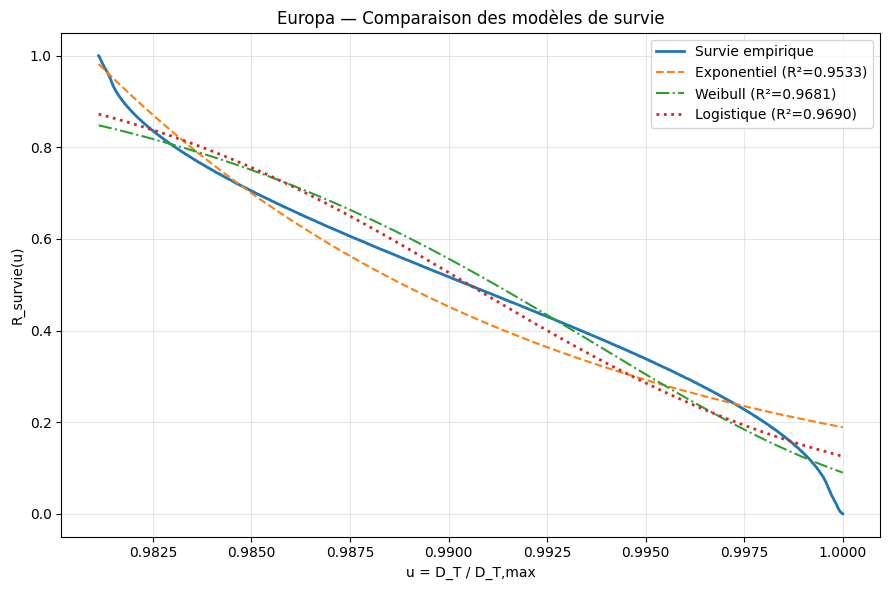

In [12]:
# ============================================================
# Étape 6B — Comparaison graphique des ajustements
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    u_fit,
    R_fit,
    linewidth=2.0,
    label="Survie empirique"
)

plt.plot(
    u_fit,
    R_pred_exp,
    linestyle="--",
    linewidth=1.5,
    label=(
        "Exponentiel "
        f"(R²={metriques_exp['R2']:.4f})"
    )
)

plt.plot(
    u_fit,
    R_pred_weibull,
    linestyle="-.",
    linewidth=1.5,
    label=(
        "Weibull "
        f"(R²={metriques_weibull['R2']:.4f})"
    )
)

plt.plot(
    u_fit,
    R_pred_logistique,
    linestyle=":",
    linewidth=2.0,
    label=(
        "Logistique "
        f"(R²={metriques_logistique['R2']:.4f})"
    )
)

plt.xlabel("u = D_T / D_T,max")
plt.ylabel("R_survie(u)")
plt.title(
    "Europa — Comparaison des modèles de survie"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# Étape 7 — Analyse angulaire GVH
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Vecteurs de transition successifs
# ------------------------------------------------------------

delta_R_1 = delta_R[:-1]
delta_R_2 = delta_R[1:]


# ------------------------------------------------------------
# 2. Produits scalaires et normes
# ------------------------------------------------------------

produits_scalaires = np.sum(
    delta_R_1 * delta_R_2,
    axis=1
)

normes_1 = np.linalg.norm(
    delta_R_1,
    axis=1
)

normes_2 = np.linalg.norm(
    delta_R_2,
    axis=1
)


# ------------------------------------------------------------
# 3. Cosinus des angles
# ------------------------------------------------------------

cos_theta = produits_scalaires / (
    normes_1 * normes_2
)

cos_theta_clipped = np.clip(
    cos_theta,
    -1.0,
    1.0
)


# ------------------------------------------------------------
# 4. Angles en radians et degrés
# ------------------------------------------------------------

theta_rad = np.arccos(
    cos_theta_clipped
)

theta_deg = np.degrees(
    theta_rad
)


# ------------------------------------------------------------
# 5. Dates associées
# ------------------------------------------------------------

dates_theta = europa[
    "Date"
].iloc[2:].reset_index(drop=True)


# ------------------------------------------------------------
# 6. Statistiques angulaires
# ------------------------------------------------------------

theta_mean = float(
    np.mean(theta_deg)
)

theta_median = float(
    np.median(theta_deg)
)

theta_std = float(
    np.std(theta_deg, ddof=0)
)

theta_min = float(
    np.min(theta_deg)
)

theta_max = float(
    np.max(theta_deg)
)

theta_q01 = float(
    np.quantile(theta_deg, 0.01)
)

theta_q05 = float(
    np.quantile(theta_deg, 0.05)
)

theta_q25 = float(
    np.quantile(theta_deg, 0.25)
)

theta_q50 = float(
    np.quantile(theta_deg, 0.50)
)

theta_q75 = float(
    np.quantile(theta_deg, 0.75)
)

theta_q90 = float(
    np.quantile(theta_deg, 0.90)
)

theta_q95 = float(
    np.quantile(theta_deg, 0.95)
)

theta_q99 = float(
    np.quantile(theta_deg, 0.99)
)


# ------------------------------------------------------------
# 7. Ratios de retournement
# ------------------------------------------------------------

R_170 = float(
    np.mean(theta_deg >= 170.0)
)

R_175 = float(
    np.mean(theta_deg >= 175.0)
)

R_180 = float(
    np.mean(theta_deg >= 179.0)
)


# ------------------------------------------------------------
# 8. Tableau détaillé
# ------------------------------------------------------------

angles_europa = pd.DataFrame({
    "Date": dates_theta,
    "theta_deg": theta_deg,
    "cos_theta": cos_theta_clipped,
})


# ------------------------------------------------------------
# 9. Résumé
# ------------------------------------------------------------

resume_theta = pd.DataFrame({
    "Observable": [
        "N_angles",
        "theta_mean_deg",
        "theta_median_deg",
        "theta_std_deg",
        "theta_min_deg",
        "theta_q01_deg",
        "theta_q05_deg",
        "theta_q25_deg",
        "theta_q50_deg",
        "theta_q75_deg",
        "theta_q90_deg",
        "theta_q95_deg",
        "theta_q99_deg",
        "theta_max_deg",
        "R_170",
        "R_175",
        "R_180",
    ],
    "Valeur": [
        len(theta_deg),
        theta_mean,
        theta_median,
        theta_std,
        theta_min,
        theta_q01,
        theta_q05,
        theta_q25,
        theta_q50,
        theta_q75,
        theta_q90,
        theta_q95,
        theta_q99,
        theta_max,
        R_170,
        R_175,
        R_180,
    ],
})


# ------------------------------------------------------------
# 10. Contrôles
# ------------------------------------------------------------

controle_theta = pd.DataFrame({
    "Controle": [
        "Nombre d'angles",
        "Angles finis",
        "Angles dans [0,180]",
        "Cosinus dans [-1,1]",
        "Écart-type fini",
        "Aucun retournement proche de 180°",
    ],
    "Valeur": [
        len(theta_deg),
        int(np.isfinite(theta_deg).sum()),
        bool(
            np.all(
                (theta_deg >= 0.0)
                & (theta_deg <= 180.0)
            )
        ),
        bool(
            np.all(
                (cos_theta_clipped >= -1.0)
                & (cos_theta_clipped <= 1.0)
            )
        ),
        theta_std,
        R_170,
    ],
    "Validation": [
        len(theta_deg) == len(D_T) - 1,
        np.isfinite(theta_deg).all(),
        np.all(
            (theta_deg >= 0.0)
            & (theta_deg <= 180.0)
        ),
        np.all(
            (cos_theta_clipped >= -1.0)
            & (cos_theta_clipped <= 1.0)
        ),
        np.isfinite(theta_std),
        R_170 == 0.0,
    ],
})


print("=" * 90)
print("ANALYSE ANGULAIRE GVH — EUROPA")
print("=" * 90)

display(resume_theta)

print("\nContrôles :")
display(controle_theta)

print("\nPremiers angles :")
display(angles_europa.head())

if controle_theta["Validation"].all():
    print("\nAnalyse angulaire validée.")
else:
    print("\nAttention : au moins un contrôle a échoué.")

ANALYSE ANGULAIRE GVH — EUROPA


,Observable,Valeur
0,N_angles,8759.000000
1,theta_mean_deg,4.224045
2,theta_median_deg,4.223538
3,theta_std_deg,0.027478
4,theta_min_deg,4.185695
5,theta_q01_deg,4.185891
6,theta_q05_deg,4.186716
7,theta_q25_deg,4.196322
8,theta_q50_deg,4.223538
9,theta_q75_deg,4.251631



Contrôles :


,Controle,Valeur,Validation
0,Nombre d'angles,8759,True
1,Angles finis,8759,True
2,"Angles dans [0,180]",True,True
3,"Cosinus dans [-1,1]",True,True
4,Écart-type fini,0.027478,True
5,Aucun retournement proche de 180°,0.0,True



Premiers angles :


,Date,theta_deg,cos_theta
0,2026-01-01 02:00:00,4.202639,0.997311
1,2026-01-01 03:00:00,4.205097,0.997308
2,2026-01-01 04:00:00,4.207668,0.997305
3,2026-01-01 05:00:00,4.210333,0.997301
4,2026-01-01 06:00:00,4.213081,0.997298



Analyse angulaire validée.


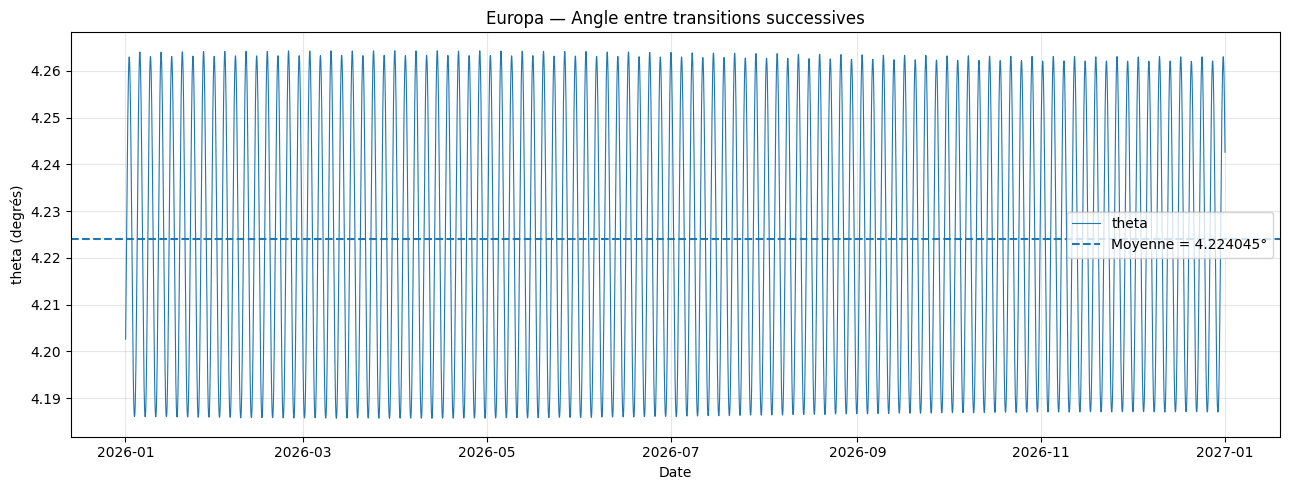

In [14]:
# ============================================================
# Étape 7B — Évolution temporelle de theta
# ============================================================

plt.figure(figsize=(13, 5))

plt.plot(
    dates_theta,
    theta_deg,
    linewidth=0.8,
    label="theta"
)

plt.axhline(
    theta_mean,
    linestyle="--",
    label=f"Moyenne = {theta_mean:.6f}°"
)

plt.xlabel("Date")
plt.ylabel("theta (degrés)")
plt.title(
    "Europa — Angle entre transitions successives"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# Étape 8 — Période géométrique dérivée de theta
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Pas temporel
# ------------------------------------------------------------

DT_HEURES = float(
    delta_t_heures.median()
)

DT_JOURS = DT_HEURES / 24.0


# ------------------------------------------------------------
# 2. Période géométrique principale
# ------------------------------------------------------------

periode_theta_geometrique_h = float(
    360.0 / theta_mean * DT_HEURES
)

periode_theta_geometrique_j = float(
    periode_theta_geometrique_h / 24.0
)

periode_theta_geometrique_s = float(
    periode_theta_geometrique_h * 3600.0
)


# ------------------------------------------------------------
# 3. Estimation avec médiane
# ------------------------------------------------------------

periode_theta_mediane_h = float(
    360.0 / theta_median * DT_HEURES
)

periode_theta_mediane_j = float(
    periode_theta_mediane_h / 24.0
)


# ------------------------------------------------------------
# 4. Bornes descriptives utilisant les quantiles
# ------------------------------------------------------------

periode_theta_q05_h = float(
    360.0 / theta_q95 * DT_HEURES
)

periode_theta_q95_h = float(
    360.0 / theta_q05 * DT_HEURES
)

periode_theta_q05_j = float(
    periode_theta_q05_h / 24.0
)

periode_theta_q95_j = float(
    periode_theta_q95_h / 24.0
)


# ------------------------------------------------------------
# 5. Dispersion relative des angles
# ------------------------------------------------------------

theta_dispersion_relative = float(
    theta_std / theta_mean
)

theta_dispersion_pourcent = float(
    100.0 * theta_dispersion_relative
)


# ------------------------------------------------------------
# 6. Tableau de résultats
# ------------------------------------------------------------

resultat_theta_geo = pd.DataFrame({
    "Observable": [
        "Pas_temporel_heures",
        "theta_mean_deg",
        "theta_median_deg",
        "theta_std_deg",
        "theta_dispersion_relative",
        "theta_dispersion_pourcent",
        "T_theta_mean_heures",
        "T_theta_mean_jours",
        "T_theta_mean_secondes",
        "T_theta_mediane_heures",
        "T_theta_mediane_jours",
        "T_theta_borne_basse_heures",
        "T_theta_borne_haute_heures",
        "T_theta_borne_basse_jours",
        "T_theta_borne_haute_jours",
    ],
    "Valeur": [
        DT_HEURES,
        theta_mean,
        theta_median,
        theta_std,
        theta_dispersion_relative,
        theta_dispersion_pourcent,
        periode_theta_geometrique_h,
        periode_theta_geometrique_j,
        periode_theta_geometrique_s,
        periode_theta_mediane_h,
        periode_theta_mediane_j,
        periode_theta_q05_h,
        periode_theta_q95_h,
        periode_theta_q05_j,
        periode_theta_q95_j,
    ],
})


# ------------------------------------------------------------
# 7. Contrôles
# ------------------------------------------------------------

controle_periode_theta = pd.DataFrame({
    "Controle": [
        "Pas temporel égal à 1 heure",
        "Période géométrique finie",
        "Période géométrique positive",
        "Période comprise entre 80 h et 90 h",
        "Moyenne et médiane cohérentes",
        "Bornes correctement ordonnées",
    ],
    "Valeur": [
        DT_HEURES,
        periode_theta_geometrique_h,
        periode_theta_geometrique_h,
        periode_theta_geometrique_h,
        abs(
            periode_theta_geometrique_h
            - periode_theta_mediane_h
        ),
        (
            periode_theta_q05_h,
            periode_theta_q95_h
        ),
    ],
    "Validation": [
        np.isclose(DT_HEURES, 1.0),
        np.isfinite(periode_theta_geometrique_h),
        periode_theta_geometrique_h > 0.0,
        80.0 <= periode_theta_geometrique_h <= 90.0,
        abs(
            periode_theta_geometrique_h
            - periode_theta_mediane_h
        ) < 0.1,
        periode_theta_q05_h
        <= periode_theta_geometrique_h
        <= periode_theta_q95_h,
    ],
})


print("=" * 90)
print("PÉRIODE GÉOMÉTRIQUE — EUROPA")
print("=" * 90)

display(resultat_theta_geo)

print("\nContrôles :")
display(controle_periode_theta)

print(
    "\nPériode géométrique moyenne : "
    f"{periode_theta_geometrique_h:.9f} h"
)

print(
    "Période géométrique moyenne : "
    f"{periode_theta_geometrique_j:.9f} jours"
)

if controle_periode_theta["Validation"].all():
    print("\nPériode géométrique validée.")
else:
    print("\nAttention : au moins un contrôle a échoué.")

PÉRIODE GÉOMÉTRIQUE — EUROPA


,Observable,Valeur
0,Pas_temporel_heures,1.000000
1,theta_mean_deg,4.224045
2,theta_median_deg,4.223538
3,theta_std_deg,0.027478
4,theta_dispersion_relative,0.006505
5,theta_dispersion_pourcent,0.650516
6,T_theta_mean_heures,85.226372
7,T_theta_mean_jours,3.551099
8,T_theta_mean_secondes,306814.939470
9,T_theta_mediane_heures,85.236604



Contrôles :


,Controle,Valeur,Validation
0,Pas temporel égal à 1 heure,1.0,True
1,Période géométrique finie,85.226372,True
2,Période géométrique positive,85.226372,True
3,Période comprise entre 80 h et 90 h,85.226372,True
4,Moyenne et médiane cohérentes,0.010232,True
5,Bornes correctement ordonnées,"(84.45398940729902, 85.98625762820076)",True



Période géométrique moyenne : 85.226372075 h
Période géométrique moyenne : 3.551098836 jours

Période géométrique validée.


In [16]:
# ============================================================
# Étape 8B — Contrôle de fermeture angulaire moyenne
# ============================================================

nombre_pas_par_orbite = float(
    periode_theta_geometrique_h / DT_HEURES
)

rotation_reconstruite_deg = float(
    nombre_pas_par_orbite * theta_mean
)

erreur_rotation_deg = float(
    abs(rotation_reconstruite_deg - 360.0)
)

controle_rotation = pd.DataFrame({
    "Observable": [
        "Nombre_pas_par_orbite",
        "Rotation_reconstruite_deg",
        "Erreur_rotation_deg",
    ],
    "Valeur": [
        nombre_pas_par_orbite,
        rotation_reconstruite_deg,
        erreur_rotation_deg,
    ],
})

display(controle_rotation)

,Observable,Valeur
0,Nombre_pas_par_orbite,85.226372
1,Rotation_reconstruite_deg,360.000000
2,Erreur_rotation_deg,0.000000


In [17]:
# ============================================================
# Étape 9 — Analyse FFT multi-observables d'Europa
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Construction des signaux
# ------------------------------------------------------------

rayon_europa = np.linalg.norm(
    R,
    axis=1
)

signaux_fft = {
    "X": np.asarray(europa["X"], dtype=float),
    "Y": np.asarray(europa["Y"], dtype=float),
    "Z": np.asarray(europa["Z"], dtype=float),
    "Rayon": np.asarray(rayon_europa, dtype=float),
    "D_T": np.asarray(D_T, dtype=float),
    "Theta": np.asarray(theta_deg, dtype=float),
}


# ------------------------------------------------------------
# 2. Fonction d'analyse FFT
# ------------------------------------------------------------

def analyser_fft(
    signal,
    dt_heures=1.0,
    periode_min_heures=20.0,
    periode_max_heures=200.0
):
    """
    Calcule la période dominante d'un signal réel régulièrement
    échantillonné, avec interpolation parabolique du pic spectral.
    """

    y = np.asarray(signal, dtype=float)

    if y.ndim != 1:
        raise ValueError("Le signal doit être un tableau unidimensionnel.")

    if len(y) < 4:
        raise ValueError("Le signal contient trop peu de valeurs.")

    if not np.isfinite(y).all():
        raise ValueError("Le signal contient des valeurs non finies.")

    # Retrait de la moyenne
    y_centre = y - np.mean(y)

    # Fenêtre de Hann pour limiter la fuite spectrale
    fenetre = np.hanning(len(y_centre))
    y_fenetre = y_centre * fenetre

    # FFT réelle
    spectre_complexe = np.fft.rfft(y_fenetre)
    frequences = np.fft.rfftfreq(
        len(y_fenetre),
        d=dt_heures
    )

    amplitudes = np.abs(spectre_complexe)

    # Exclusion de la fréquence nulle
    masque_non_nul = frequences > 0.0

    frequences = frequences[masque_non_nul]
    amplitudes = amplitudes[masque_non_nul]

    periodes = 1.0 / frequences

    # Domaine de recherche
    masque_periode = (
        (periodes >= periode_min_heures)
        & (periodes <= periode_max_heures)
    )

    if not np.any(masque_periode):
        raise ValueError(
            "Aucune fréquence dans l'intervalle de périodes demandé."
        )

    frequences_zone = frequences[masque_periode]
    amplitudes_zone = amplitudes[masque_periode]
    periodes_zone = periodes[masque_periode]

    indice_local = int(
        np.argmax(amplitudes_zone)
    )

    frequence_pic_brute = float(
        frequences_zone[indice_local]
    )

    periode_pic_brute = float(
        1.0 / frequence_pic_brute
    )

    amplitude_pic = float(
        amplitudes_zone[indice_local]
    )

    # --------------------------------------------------------
    # Interpolation parabolique autour du maximum
    # --------------------------------------------------------

    frequence_pic_interpolee = frequence_pic_brute
    decalage_bins = 0.0

    if 0 < indice_local < len(amplitudes_zone) - 1:

        alpha = amplitudes_zone[indice_local - 1]
        beta = amplitudes_zone[indice_local]
        gamma = amplitudes_zone[indice_local + 1]

        denominateur = (
            alpha
            - 2.0 * beta
            + gamma
        )

        if not np.isclose(denominateur, 0.0):

            decalage_bins = float(
                0.5
                * (alpha - gamma)
                / denominateur
            )

            pas_frequence = float(
                frequences_zone[1]
                - frequences_zone[0]
            )

            frequence_pic_interpolee = float(
                frequence_pic_brute
                + decalage_bins * pas_frequence
            )

    periode_pic_interpolee = float(
        1.0 / frequence_pic_interpolee
    )

    resolution_frequence = float(
        1.0 / (
            len(y)
            * dt_heures
        )
    )

    resolution_periode_approx = float(
        resolution_frequence
        / frequence_pic_interpolee**2
    )

    return {
        "N": int(len(y)),
        "dt_heures": float(dt_heures),
        "frequence_brute_h_inv": frequence_pic_brute,
        "periode_brute_heures": periode_pic_brute,
        "frequence_interpolee_h_inv": frequence_pic_interpolee,
        "periode_interpolee_heures": periode_pic_interpolee,
        "periode_interpolee_jours": periode_pic_interpolee / 24.0,
        "amplitude_pic": amplitude_pic,
        "decalage_bins": decalage_bins,
        "resolution_frequence_h_inv": resolution_frequence,
        "resolution_periode_approx_h": resolution_periode_approx,
        "frequences": frequences,
        "amplitudes": amplitudes,
        "periodes": periodes,
    }


# ------------------------------------------------------------
# 3. Exécution sur les six signaux
# ------------------------------------------------------------

resultats_fft = {}

for nom_signal, signal in signaux_fft.items():

    resultats_fft[nom_signal] = analyser_fft(
        signal=signal,
        dt_heures=DT_HEURES,
        periode_min_heures=60.0,
        periode_max_heures=110.0
    )


# ------------------------------------------------------------
# 4. Tableau résumé
# ------------------------------------------------------------

resume_fft_io = pd.DataFrame([
    {
        "Signal": nom_signal,
        "N": resultat["N"],
        "Periode_brute_heures":
            resultat["periode_brute_heures"],
        "Periode_interpolee_heures":
            resultat["periode_interpolee_heures"],
        "Periode_interpolee_jours":
            resultat["periode_interpolee_jours"],
        "Frequence_interpolee_h_inv":
            resultat["frequence_interpolee_h_inv"],
        "Resolution_periode_approx_h":
            resultat["resolution_periode_approx_h"],
        "Ecart_vs_theta_heures":
            resultat["periode_interpolee_heures"]
            - periode_theta_geometrique_h,
        "Ecart_vs_theta_secondes":
            (
                resultat["periode_interpolee_heures"]
                - periode_theta_geometrique_h
            ) * 3600.0,
        "Ecart_relatif_vs_theta_pct":
            100.0
            * (
                resultat["periode_interpolee_heures"]
                - periode_theta_geometrique_h
            )
            / periode_theta_geometrique_h,
    }
    for nom_signal, resultat in resultats_fft.items()
])


# Nom plus cohérent pour Europa
resume_fft_europa = resume_fft_io.copy()


# ------------------------------------------------------------
# 5. Moyenne FFT cartésienne X-Y-Z
# ------------------------------------------------------------

masque_xyz = resume_fft_europa[
    "Signal"
].isin(["X", "Y", "Z"])

periode_fft_xyz_mean_h = float(
    resume_fft_europa.loc[
        masque_xyz,
        "Periode_interpolee_heures"
    ].mean()
)

periode_fft_xyz_mean_j = float(
    periode_fft_xyz_mean_h / 24.0
)

ecart_fft_xyz_theta_h = float(
    periode_fft_xyz_mean_h
    - periode_theta_geometrique_h
)

ecart_fft_xyz_theta_s = float(
    ecart_fft_xyz_theta_h * 3600.0
)

ecart_fft_xyz_theta_pct = float(
    100.0
    * ecart_fft_xyz_theta_h
    / periode_theta_geometrique_h
)


# ------------------------------------------------------------
# 6. Résumé cartésien
# ------------------------------------------------------------

resume_fft_xyz = pd.DataFrame({
    "Observable": [
        "T_FFT_XYZ_mean_heures",
        "T_FFT_XYZ_mean_jours",
        "T_theta_heures",
        "Ecart_FFT_XYZ_theta_heures",
        "Ecart_FFT_XYZ_theta_secondes",
        "Ecart_FFT_XYZ_theta_pourcent",
    ],
    "Valeur": [
        periode_fft_xyz_mean_h,
        periode_fft_xyz_mean_j,
        periode_theta_geometrique_h,
        ecart_fft_xyz_theta_h,
        ecart_fft_xyz_theta_s,
        ecart_fft_xyz_theta_pct,
    ],
})


# ------------------------------------------------------------
# 7. Contrôles
# ------------------------------------------------------------

controle_fft = pd.DataFrame({
    "Controle": [
        "Six signaux analysés",
        "Toutes les périodes sont finies",
        "Toutes les périodes sont positives",
        "Toutes les périodes sont entre 60 h et 110 h",
        "Périodes XYZ mutuellement proches",
        "Moyenne XYZ proche de la période theta",
    ],
    "Valeur": [
        len(resume_fft_europa),
        bool(
            np.isfinite(
                resume_fft_europa[
                    "Periode_interpolee_heures"
                ]
            ).all()
        ),
        bool(
            (
                resume_fft_europa[
                    "Periode_interpolee_heures"
                ] > 0
            ).all()
        ),
        bool(
            resume_fft_europa[
                "Periode_interpolee_heures"
            ].between(60.0, 110.0).all()
        ),
        float(
            resume_fft_europa.loc[
                masque_xyz,
                "Periode_interpolee_heures"
            ].max()
            -
            resume_fft_europa.loc[
                masque_xyz,
                "Periode_interpolee_heures"
            ].min()
        ),
        abs(ecart_fft_xyz_theta_pct),
    ],
    "Validation": [
        len(resume_fft_europa) == 6,
        np.isfinite(
            resume_fft_europa[
                "Periode_interpolee_heures"
            ]
        ).all(),
        (
            resume_fft_europa[
                "Periode_interpolee_heures"
            ] > 0
        ).all(),
        resume_fft_europa[
            "Periode_interpolee_heures"
        ].between(60.0, 110.0).all(),
        (
            resume_fft_europa.loc[
                masque_xyz,
                "Periode_interpolee_heures"
            ].max()
            -
            resume_fft_europa.loc[
                masque_xyz,
                "Periode_interpolee_heures"
            ].min()
        ) < 0.2,
        abs(ecart_fft_xyz_theta_pct) < 1.0,
    ],
})


print("=" * 90)
print("ANALYSE FFT — EUROPA")
print("=" * 90)

display(resume_fft_europa)

print("\nRésumé FFT cartésienne :")
display(resume_fft_xyz)

print("\nContrôles :")
display(controle_fft)

if controle_fft["Validation"].all():
    print("\nAnalyse FFT validée.")
else:
    print("\nAttention : au moins un contrôle FFT a échoué.")

ANALYSE FFT — EUROPA


,Signal,N,Periode_brute_heures,Periode_interpolee_heures,Periode_interpolee_jours,Frequence_interpolee_h_inv,Resolution_periode_approx_h,Ecart_vs_theta_heures,Ecart_vs_theta_secondes,Ecart_relatif_vs_theta_pct
0,X,8761,85.058252,85.191603,3.549650,0.011738,0.828400,-0.034769,-125.167199,-0.040796
1,Y,8761,85.058252,85.191576,3.549649,0.011738,0.828399,-0.034796,-125.266623,-0.040828
2,Z,8761,85.058252,85.192678,3.549695,0.011738,0.828421,-0.033694,-121.299797,-0.039535
3,Rayon,8761,84.240385,84.594841,3.524785,0.011821,0.816835,-0.631531,-2273.510855,-0.741004
4,D_T,8760,84.230769,84.599507,3.524979,0.011820,0.817018,-0.626865,-2256.712508,-0.735529
5,Theta,8759,84.221154,84.604777,3.525199,0.011820,0.817213,-0.621596,-2237.743907,-0.729346



Résumé FFT cartésienne :


,Observable,Valeur
0,T_FFT_XYZ_mean_heures,85.191952
1,T_FFT_XYZ_mean_jours,3.549665
2,T_theta_heures,85.226372
3,Ecart_FFT_XYZ_theta_heures,-0.034420
4,Ecart_FFT_XYZ_theta_secondes,-123.911206
5,Ecart_FFT_XYZ_theta_pourcent,-0.040386



Contrôles :


,Controle,Valeur,Validation
0,Six signaux analysés,6,True
1,Toutes les périodes sont finies,True,True
2,Toutes les périodes sont positives,True,True
3,Toutes les périodes sont entre 60 h et 110 h,True,True
4,Périodes XYZ mutuellement proches,0.001102,True
5,Moyenne XYZ proche de la période theta,0.040386,True



Analyse FFT validée.


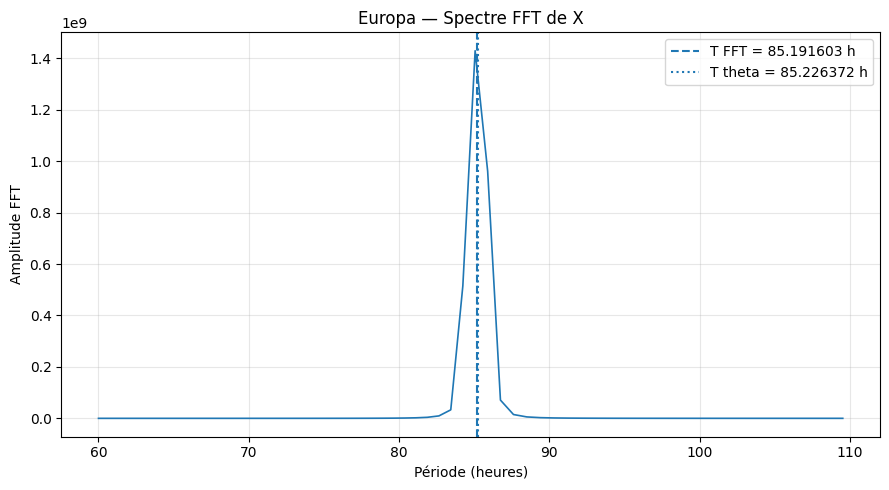

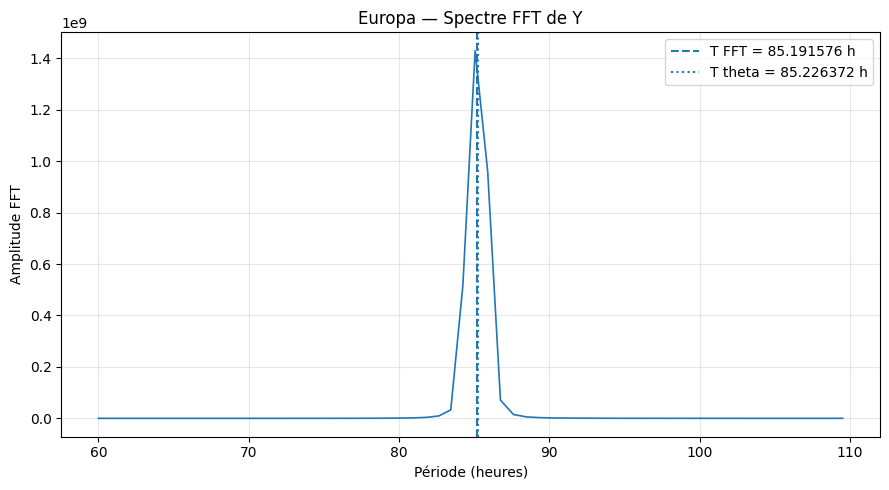

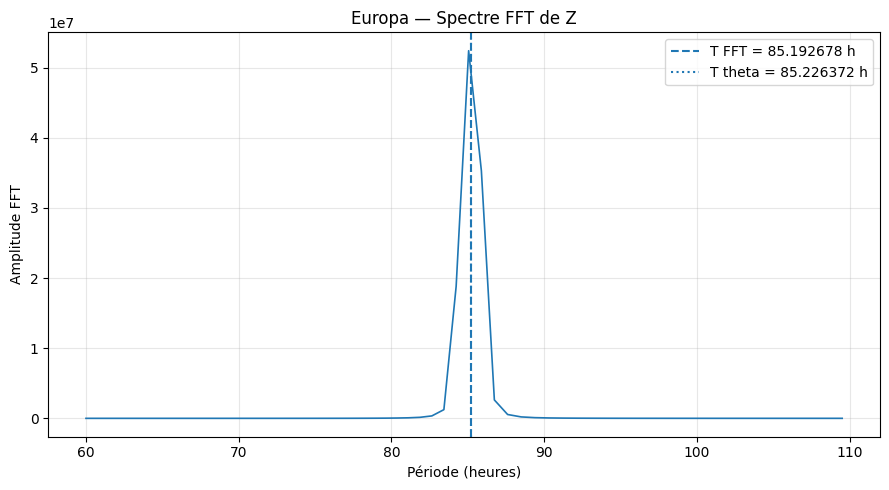

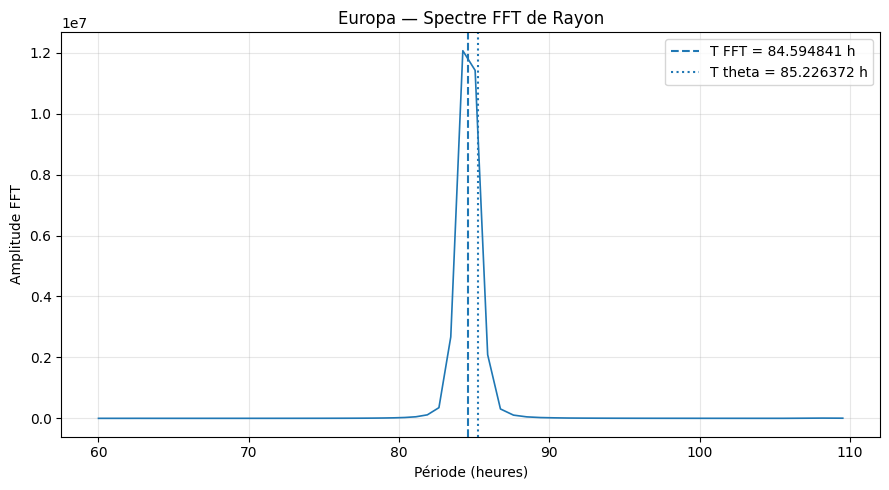

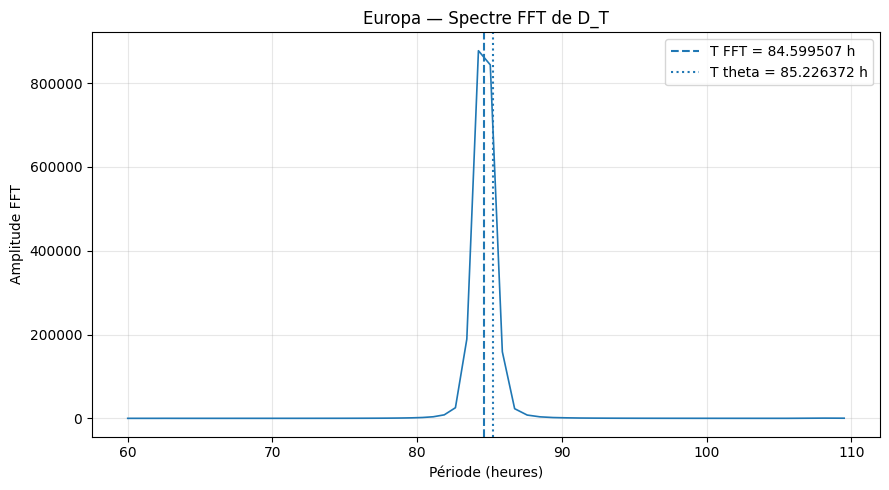

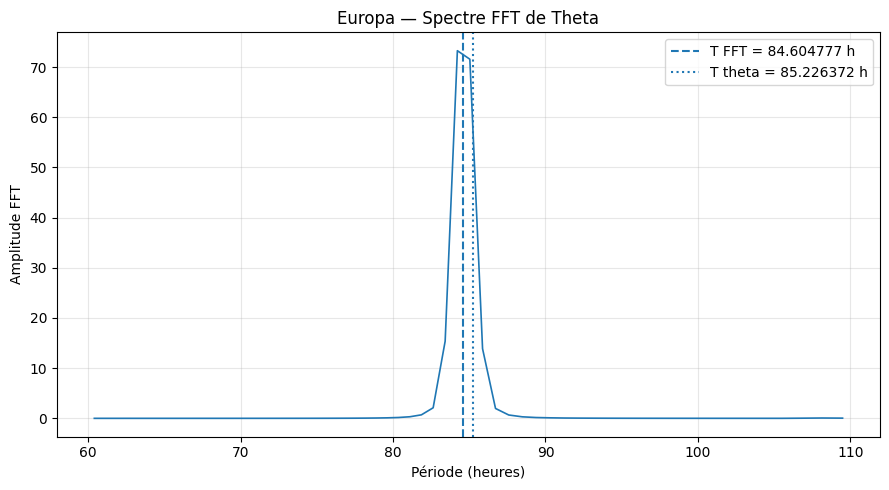

In [18]:
# ============================================================
# Étape 9B — Spectres FFT
# ============================================================

for nom_signal, resultat in resultats_fft.items():

    masque_affichage = (
        (resultat["periodes"] >= 60.0)
        & (resultat["periodes"] <= 110.0)
    )

    plt.figure(figsize=(9, 5))

    plt.plot(
        resultat["periodes"][masque_affichage],
        resultat["amplitudes"][masque_affichage],
        linewidth=1.2
    )

    plt.axvline(
        resultat["periode_interpolee_heures"],
        linestyle="--",
        label=(
            f"T FFT = "
            f"{resultat['periode_interpolee_heures']:.6f} h"
        )
    )

    plt.axvline(
        periode_theta_geometrique_h,
        linestyle=":",
        label=(
            f"T theta = "
            f"{periode_theta_geometrique_h:.6f} h"
        )
    )

    plt.xlabel("Période (heures)")
    plt.ylabel("Amplitude FFT")
    plt.title(
        f"Europa — Spectre FFT de {nom_signal}"
    )
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [19]:
# ============================================================
# Étape 10 — Fermeture orbitale d'Europa
# ============================================================

import numpy as np
import pandas as pd

from scipy.interpolate import CubicSpline
from scipy.optimize import minimize_scalar


# ------------------------------------------------------------
# 1. Temps en heures depuis la première observation
# ------------------------------------------------------------

temps_heures = (
    europa["Date"] - europa["Date"].iloc[0]
).dt.total_seconds().to_numpy() / 3600.0


# ------------------------------------------------------------
# 2. Interpolateurs cubiques X, Y, Z
# ------------------------------------------------------------

spline_X = CubicSpline(
    temps_heures,
    R[:, 0]
)

spline_Y = CubicSpline(
    temps_heures,
    R[:, 1]
)

spline_Z = CubicSpline(
    temps_heures,
    R[:, 2]
)


def position_interpolee(t):
    """
    Retourne les positions interpolées pour un tableau de temps t.
    """

    t = np.asarray(t, dtype=float)

    return np.column_stack([
        spline_X(t),
        spline_Y(t),
        spline_Z(t),
    ])


# ------------------------------------------------------------
# 3. Fonction de défaut de fermeture
# ------------------------------------------------------------

def metriques_fermeture(T_heures):
    """
    Compare R(t+T) à R(t) sur toute la zone temporelle valide.
    """

    T_heures = float(T_heures)

    masque_valide = (
        temps_heures + T_heures
        <= temps_heures[-1]
    )

    t0 = temps_heures[masque_valide]

    R_t = R[masque_valide]

    R_t_plus_T = position_interpolee(
        t0 + T_heures
    )

    ecarts = np.linalg.norm(
        R_t_plus_T - R_t,
        axis=1
    )

    mean_km = float(
        np.mean(ecarts)
    )

    rms_km = float(
        np.sqrt(
            np.mean(ecarts**2)
        )
    )

    max_km = float(
        np.max(ecarts)
    )

    return {
        "N_comparaisons": int(len(ecarts)),
        "Defaut_mean_km": mean_km,
        "Defaut_rms_km": rms_km,
        "Defaut_max_km": max_km,
        "Ecarts_km": ecarts,
    }


def objectif_fermeture(T_heures):
    return metriques_fermeture(
        T_heures
    )["Defaut_mean_km"]


# ------------------------------------------------------------
# 4. Recherche grossière
# ------------------------------------------------------------

grille_T = np.linspace(
    83.0,
    87.0,
    801
)

grille_C = np.array([
    objectif_fermeture(T)
    for T in grille_T
])

indice_min_grille = int(
    np.argmin(grille_C)
)

T_grille_best = float(
    grille_T[indice_min_grille]
)

C_grille_best = float(
    grille_C[indice_min_grille]
)


# ------------------------------------------------------------
# 5. Optimisation continue
# ------------------------------------------------------------

resultat_optimisation = minimize_scalar(
    objectif_fermeture,
    bounds=(
        max(83.0, T_grille_best - 0.2),
        min(87.0, T_grille_best + 0.2)
    ),
    method="bounded",
    options={
        "xatol": 1e-10,
        "maxiter": 1000,
    }
)

if not resultat_optimisation.success:
    raise RuntimeError(
        "L'optimisation de fermeture a échoué."
    )

periode_fermeture_h = float(
    resultat_optimisation.x
)

periode_fermeture_j = float(
    periode_fermeture_h / 24.0
)

periode_fermeture_s = float(
    periode_fermeture_h * 3600.0
)


# ------------------------------------------------------------
# 6. Métriques au meilleur T
# ------------------------------------------------------------

metriques_best = metriques_fermeture(
    periode_fermeture_h
)

defaut_mean_km = float(
    metriques_best["Defaut_mean_km"]
)

defaut_rms_km = float(
    metriques_best["Defaut_rms_km"]
)

defaut_max_km = float(
    metriques_best["Defaut_max_km"]
)


# ------------------------------------------------------------
# 7. Normalisation par le rayon orbital moyen
# ------------------------------------------------------------

rayon_mean_km = float(
    np.mean(rayon_europa)
)

defaut_mean_normalise = float(
    defaut_mean_km / rayon_mean_km
)

defaut_rms_normalise = float(
    defaut_rms_km / rayon_mean_km
)


# ------------------------------------------------------------
# 8. Angle moyen de fermeture
# ------------------------------------------------------------

masque_best = (
    temps_heures + periode_fermeture_h
    <= temps_heures[-1]
)

t_best = temps_heures[
    masque_best
]

R_depart = R[
    masque_best
]

R_retour = position_interpolee(
    t_best + periode_fermeture_h
)

produits_fermeture = np.sum(
    R_depart * R_retour,
    axis=1
)

normes_depart = np.linalg.norm(
    R_depart,
    axis=1
)

normes_retour = np.linalg.norm(
    R_retour,
    axis=1
)

cos_fermeture = np.clip(
    produits_fermeture
    / (normes_depart * normes_retour),
    -1.0,
    1.0
)

angles_fermeture_deg = np.degrees(
    np.arccos(cos_fermeture)
)

angle_fermeture_mean_deg = float(
    np.mean(angles_fermeture_deg)
)

angle_fermeture_max_deg = float(
    np.max(angles_fermeture_deg)
)


# ------------------------------------------------------------
# 9. Comparaison des périodes
# ------------------------------------------------------------

ecart_closure_theta_h = float(
    periode_fermeture_h
    - periode_theta_geometrique_h
)

ecart_closure_theta_s = float(
    ecart_closure_theta_h * 3600.0
)

ecart_closure_fft_h = float(
    periode_fermeture_h
    - periode_fft_xyz_mean_h
)

ecart_closure_fft_s = float(
    ecart_closure_fft_h * 3600.0
)


# ------------------------------------------------------------
# 10. Résumé
# ------------------------------------------------------------

resume_fermeture_europa = pd.DataFrame({
    "Observable": [
        "T_grille_best_heures",
        "C_grille_best_km",
        "T_closure_heures",
        "T_closure_jours",
        "T_closure_secondes",
        "Defaut_mean_km",
        "Defaut_rms_km",
        "Defaut_max_km",
        "Rayon_mean_km",
        "Defaut_mean_normalise",
        "Defaut_rms_normalise",
        "Angle_fermeture_mean_deg",
        "Angle_fermeture_max_deg",
        "T_theta_heures",
        "T_FFT_XYZ_heures",
        "Ecart_closure_theta_heures",
        "Ecart_closure_theta_secondes",
        "Ecart_closure_FFT_heures",
        "Ecart_closure_FFT_secondes",
    ],
    "Valeur": [
        T_grille_best,
        C_grille_best,
        periode_fermeture_h,
        periode_fermeture_j,
        periode_fermeture_s,
        defaut_mean_km,
        defaut_rms_km,
        defaut_max_km,
        rayon_mean_km,
        defaut_mean_normalise,
        defaut_rms_normalise,
        angle_fermeture_mean_deg,
        angle_fermeture_max_deg,
        periode_theta_geometrique_h,
        periode_fft_xyz_mean_h,
        ecart_closure_theta_h,
        ecart_closure_theta_s,
        ecart_closure_fft_h,
        ecart_closure_fft_s,
    ],
})


# ------------------------------------------------------------
# 11. Contrôles
# ------------------------------------------------------------

controle_fermeture = pd.DataFrame({
    "Controle": [
        "Optimisation réussie",
        "Période entre 83 h et 87 h",
        "Défaut moyen fini",
        "Défaut moyen positif",
        "Défaut normalisé inférieur à 0.1 %",
        "Angle moyen inférieur à 0.1 degré",
        "Fermeture proche de la période theta",
    ],
    "Valeur": [
        resultat_optimisation.success,
        periode_fermeture_h,
        defaut_mean_km,
        defaut_mean_km,
        defaut_mean_normalise,
        angle_fermeture_mean_deg,
        abs(ecart_closure_theta_s),
    ],
    "Validation": [
        resultat_optimisation.success,
        83.0 <= periode_fermeture_h <= 87.0,
        np.isfinite(defaut_mean_km),
        defaut_mean_km >= 0.0,
        defaut_mean_normalise < 1e-3,
        angle_fermeture_mean_deg < 0.1,
        abs(ecart_closure_theta_s) < 60.0,
    ],
})


print("=" * 90)
print("FERMETURE ORBITALE — EUROPA")
print("=" * 90)

display(resume_fermeture_europa)

print("\nContrôles :")
display(controle_fermeture)

if controle_fermeture["Validation"].all():
    print("\nFermeture orbitale validée.")
else:
    print("\nAttention : au moins un contrôle a échoué.")

FERMETURE ORBITALE — EUROPA


,Observable,Valeur
0,T_grille_best_heures,85.225000
1,C_grille_best_km,457.744465
2,T_closure_heures,85.227412
3,T_closure_jours,3.551142
4,T_closure_secondes,306818.683039
5,Defaut_mean_km,449.030863
6,Defaut_rms_km,505.767930
7,Defaut_max_km,1067.602958
8,Rayon_mean_km,671073.903089
9,Defaut_mean_normalise,0.000669



Contrôles :


,Controle,Valeur,Validation
0,Optimisation réussie,True,True
1,Période entre 83 h et 87 h,85.227412,True
2,Défaut moyen fini,449.030863,True
3,Défaut moyen positif,449.030863,True
4,Défaut normalisé inférieur à 0.1 %,0.000669,True
5,Angle moyen inférieur à 0.1 degré,0.031798,True
6,Fermeture proche de la période theta,3.74357,True



Fermeture orbitale validée.


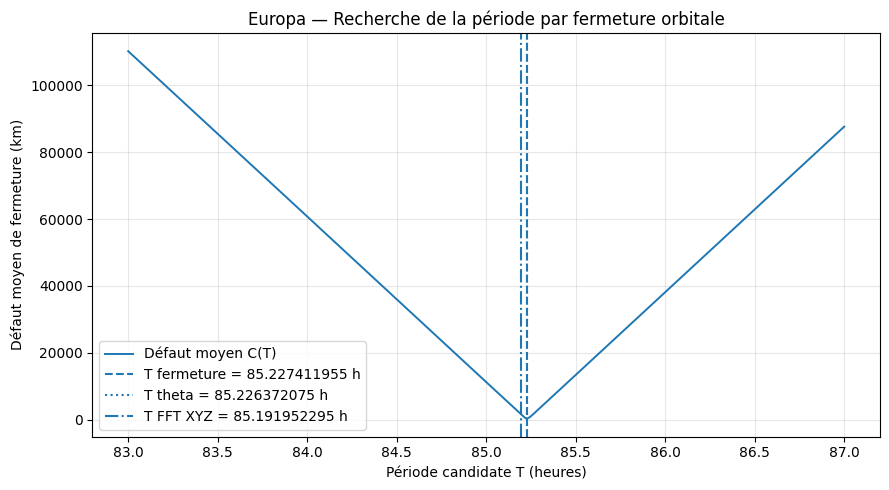

In [20]:
# ============================================================
# Étape 10B — Courbe C(T)
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    grille_T,
    grille_C,
    linewidth=1.4,
    label="Défaut moyen C(T)"
)

plt.axvline(
    periode_fermeture_h,
    linestyle="--",
    label=(
        f"T fermeture = "
        f"{periode_fermeture_h:.9f} h"
    )
)

plt.axvline(
    periode_theta_geometrique_h,
    linestyle=":",
    label=(
        f"T theta = "
        f"{periode_theta_geometrique_h:.9f} h"
    )
)

plt.axvline(
    periode_fft_xyz_mean_h,
    linestyle="-.",
    label=(
        f"T FFT XYZ = "
        f"{periode_fft_xyz_mean_h:.9f} h"
    )
)

plt.xlabel("Période candidate T (heures)")
plt.ylabel("Défaut moyen de fermeture (km)")
plt.title(
    "Europa — Recherche de la période par fermeture orbitale"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# Étape 10C — Comparaison theta / FFT / fermeture
# ============================================================

comparaison_periodes_europa = pd.DataFrame({
    "Methode": [
        "Theta géométrique",
        "FFT XYZ moyenne",
        "Fermeture orbitale",
    ],
    "Periode_heures": [
        periode_theta_geometrique_h,
        periode_fft_xyz_mean_h,
        periode_fermeture_h,
    ],
    "Periode_jours": [
        periode_theta_geometrique_h / 24.0,
        periode_fft_xyz_mean_h / 24.0,
        periode_fermeture_h / 24.0,
    ],
})

comparaison_periodes_europa[
    "Ecart_vs_closure_secondes"
] = (
    comparaison_periodes_europa[
        "Periode_heures"
    ]
    - periode_fermeture_h
) * 3600.0

display(comparaison_periodes_europa)

,Methode,Periode_heures,Periode_jours,Ecart_vs_closure_secondes
0,Theta géométrique,85.226372,3.551099,-3.743570
1,FFT XYZ moyenne,85.191952,3.549665,-127.654776
2,Fermeture orbitale,85.227412,3.551142,0.000000


In [22]:
# ============================================================
# Étape 11 — Validation externe de la période d'Europa
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Période sidérale conventionnelle adoptée
# ------------------------------------------------------------

T_REFERENCE_JOURS = 3.551181

T_REFERENCE_HEURES = float(
    T_REFERENCE_JOURS * 24.0
)

T_REFERENCE_SECONDES = float(
    T_REFERENCE_HEURES * 3600.0
)


# ------------------------------------------------------------
# 2. Méthodes à comparer
# ------------------------------------------------------------

methodes = {
    "Theta géométrique": periode_theta_geometrique_h,
    "Fermeture orbitale": periode_fermeture_h,
    "FFT XYZ moyenne": periode_fft_xyz_mean_h,
}


# ------------------------------------------------------------
# 3. Tableau de validation
# ------------------------------------------------------------

lignes_validation = []

for methode, periode_h in methodes.items():

    erreur_h = float(
        periode_h - T_REFERENCE_HEURES
    )

    erreur_s = float(
        erreur_h * 3600.0
    )

    erreur_absolue_s = float(
        abs(erreur_s)
    )

    erreur_relative = float(
        erreur_h / T_REFERENCE_HEURES
    )

    erreur_ppm = float(
        1e6 * erreur_relative
    )

    lignes_validation.append({
        "Methode": methode,
        "Periode_heures": periode_h,
        "Periode_jours": periode_h / 24.0,
        "Erreur_signee_secondes": erreur_s,
        "Erreur_absolue_secondes": erreur_absolue_s,
        "Erreur_relative": erreur_relative,
        "Erreur_ppm": erreur_ppm,
    })


validation_periode_europa = pd.DataFrame(
    lignes_validation
).sort_values(
    "Erreur_absolue_secondes"
).reset_index(drop=True)


# ------------------------------------------------------------
# 4. Résumé de la référence
# ------------------------------------------------------------

reference_europa = pd.DataFrame({
    "Observable": [
        "Reference_adoptee_jours",
        "Reference_adoptee_heures",
        "Reference_adoptee_secondes",
    ],
    "Valeur": [
        T_REFERENCE_JOURS,
        T_REFERENCE_HEURES,
        T_REFERENCE_SECONDES,
    ],
})


# ------------------------------------------------------------
# 5. Contrôles
# ------------------------------------------------------------

controle_validation_externe = pd.DataFrame({
    "Controle": [
        "Trois méthodes comparées",
        "Toutes les périodes sont finies",
        "Theta sous 10 secondes",
        "Fermeture sous 10 secondes",
        "FFT sous 5 minutes",
    ],
    "Valeur": [
        len(validation_periode_europa),
        bool(
            np.isfinite(
                validation_periode_europa[
                    "Periode_heures"
                ]
            ).all()
        ),
        float(
            validation_periode_europa.loc[
                validation_periode_europa["Methode"]
                == "Theta géométrique",
                "Erreur_absolue_secondes"
            ].iloc[0]
        ),
        float(
            validation_periode_europa.loc[
                validation_periode_europa["Methode"]
                == "Fermeture orbitale",
                "Erreur_absolue_secondes"
            ].iloc[0]
        ),
        float(
            validation_periode_europa.loc[
                validation_periode_europa["Methode"]
                == "FFT XYZ moyenne",
                "Erreur_absolue_secondes"
            ].iloc[0]
        ),
    ],
    "Validation": [
        len(validation_periode_europa) == 3,
        np.isfinite(
            validation_periode_europa[
                "Periode_heures"
            ]
        ).all(),
        float(
            validation_periode_europa.loc[
                validation_periode_europa["Methode"]
                == "Theta géométrique",
                "Erreur_absolue_secondes"
            ].iloc[0]
        ) < 10.0,
        float(
            validation_periode_europa.loc[
                validation_periode_europa["Methode"]
                == "Fermeture orbitale",
                "Erreur_absolue_secondes"
            ].iloc[0]
        ) < 10.0,
        float(
            validation_periode_europa.loc[
                validation_periode_europa["Methode"]
                == "FFT XYZ moyenne",
                "Erreur_absolue_secondes"
            ].iloc[0]
        ) < 300.0,
    ],
})


print("=" * 90)
print("VALIDATION EXTERNE DE LA PÉRIODE — EUROPA")
print("=" * 90)

print(
    f"Référence adoptée : "
    f"{T_REFERENCE_JOURS:.9f} jours"
)

display(reference_europa)

print("\nComparaison des méthodes :")
display(validation_periode_europa)

print("\nContrôles :")
display(controle_validation_externe)

if controle_validation_externe["Validation"].all():
    print("\nValidation externe réussie.")
else:
    print("\nAttention : au moins un contrôle a échoué.")

VALIDATION EXTERNE DE LA PÉRIODE — EUROPA
Référence adoptée : 3.551181000 jours


,Observable,Valeur
0,Reference_adoptee_jours,3.551181
1,Reference_adoptee_heures,85.228344
2,Reference_adoptee_secondes,306822.038400



Comparaison des méthodes :


,Methode,Periode_heures,Periode_jours,Erreur_signee_secondes,Erreur_absolue_secondes,Erreur_relative,Erreur_ppm
0,Fermeture orbitale,85.227412,3.551142,-3.355361,3.355361,-0.000011,-10.935852
1,Theta géométrique,85.226372,3.551099,-7.098930,7.098930,-0.000023,-23.136963
2,FFT XYZ moyenne,85.191952,3.549665,-131.010136,131.010136,-0.000427,-426.990633



Contrôles :


,Controle,Valeur,Validation
0,Trois méthodes comparées,3,True
1,Toutes les périodes sont finies,True,True
2,Theta sous 10 secondes,7.09893,True
3,Fermeture sous 10 secondes,3.355361,True
4,FFT sous 5 minutes,131.010136,True



Validation externe réussie.


In [23]:
# ============================================================
# Étape 12 — Export des résultats du pipeline Europa
# ============================================================

import os
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Dossier d'export
# ------------------------------------------------------------

dossier_export = "exports_europa"
os.makedirs(dossier_export, exist_ok=True)


# ------------------------------------------------------------
# 2. Construction du tableau des observables
# ------------------------------------------------------------

observables_export = pd.DataFrame({
    "Observable": [
        "N_observations",
        "N_transitions",

        "D_T_mean_km",
        "D_T_std_km",
        "D_T_norm_std",
        "D_T_min_km",
        "D_T_median_km",
        "D_T_max_km",

        "Quantile_critique",
        "D_c_km",
        "N_supercritique",
        "R_super",

        "u_min",
        "u_mean",
        "u_median",
        "u_max",
        "u_c",

        "Meilleur_modele_survie",
        "Logistique_u0",
        "Logistique_k",
        "Logistique_R2",
        "Logistique_RMSE",
        "Weibull_lambda",
        "Weibull_k",
        "Weibull_R2",
        "Exponentiel_A_H",
        "Exponentiel_B_H",
        "Exponentiel_R2",

        "N_angles",
        "theta_mean_deg",
        "theta_median_deg",
        "theta_std_deg",
        "theta_min_deg",
        "theta_q05_deg",
        "theta_q95_deg",
        "theta_q99_deg",
        "theta_max_deg",
        "R_170",
        "R_175",
        "R_180",

        "T_theta_heures",
        "T_theta_jours",
        "T_theta_secondes",
    ],

    "Valeur": [
        int(len(europa)),
        int(len(D_T)),

        float(D_T_mean),
        float(D_T_std),
        float(S_T_norm),
        float(D_T_min),
        float(D_T_median),
        float(D_T_max),

        float(Q_CRITIQUE),
        float(D_c),
        int(n_super),
        float(R_super),

        float(np.min(u)),
        float(np.mean(u)),
        float(np.median(u)),
        float(np.max(u)),
        float(u_c),

        str(meilleur_modele_survie),
        float(u0_logistique),
        float(k_logistique),
        float(metriques_logistique["R2"]),
        float(metriques_logistique["RMSE"]),
        float(lambda_weibull),
        float(k_weibull),
        float(metriques_weibull["R2"]),
        float(A_H_exp),
        float(B_H_exp),
        float(metriques_exp["R2"]),

        int(len(theta_deg)),
        float(theta_mean),
        float(theta_median),
        float(theta_std),
        float(theta_min),
        float(theta_q05),
        float(theta_q95),
        float(theta_q99),
        float(theta_max),
        float(R_170),
        float(R_175),
        float(R_180),

        float(periode_theta_geometrique_h),
        float(periode_theta_geometrique_j),
        float(periode_theta_geometrique_s),
    ],
})


# ------------------------------------------------------------
# 3. Export observables
# ------------------------------------------------------------

chemin_observables = os.path.join(
    dossier_export,
    "GVH_Europa_Observables_0.1.csv"
)

observables_export.to_csv(
    chemin_observables,
    index=False
)


# ------------------------------------------------------------
# 4. Export FFT
# ------------------------------------------------------------

if "resume_fft_europa" not in globals():
    raise NameError(
        "resume_fft_europa est absent. "
        "Exécuter d'abord l'étape FFT."
    )

fft_export = resume_fft_europa.copy()

chemin_fft = os.path.join(
    dossier_export,
    "GVH_Europa_FFT_0.1.csv"
)

fft_export.to_csv(
    chemin_fft,
    index=False
)


# ------------------------------------------------------------
# 5. Export fermeture
# ------------------------------------------------------------

if "resume_fermeture_europa" not in globals():
    raise NameError(
        "resume_fermeture_europa est absent. "
        "Exécuter d'abord l'étape de fermeture."
    )

closure_export = resume_fermeture_europa.copy()

chemin_closure = os.path.join(
    dossier_export,
    "GVH_Europa_Closure_0.1.csv"
)

closure_export.to_csv(
    chemin_closure,
    index=False
)


# ------------------------------------------------------------
# 6. Export validation externe
# ------------------------------------------------------------

if "validation_periode_europa" not in globals():
    raise NameError(
        "validation_periode_europa est absent. "
        "Exécuter d'abord la validation externe."
    )

validation_export = validation_periode_europa.copy()

chemin_validation = os.path.join(
    dossier_export,
    "GVH_Europa_Validation_0.1.csv"
)

validation_export.to_csv(
    chemin_validation,
    index=False
)


# ------------------------------------------------------------
# 7. Contrôle des fichiers produits
# ------------------------------------------------------------

fichiers_generes = [
    chemin_observables,
    chemin_fft,
    chemin_closure,
    chemin_validation,
]

controle_exports = pd.DataFrame({
    "Fichier": fichiers_generes,
    "Existe": [
        os.path.exists(fichier)
        for fichier in fichiers_generes
    ],
    "Taille_octets": [
        os.path.getsize(fichier)
        if os.path.exists(fichier)
        else 0
        for fichier in fichiers_generes
    ],
})


print("=" * 90)
print("EXPORTS DU PIPELINE EUROPA")
print("=" * 90)

display(controle_exports)

print("\nAperçu des observables :")
display(observables_export)

if controle_exports["Existe"].all():
    print("\nLes quatre fichiers CSV ont été générés avec succès.")
else:
    print("\nAttention : au moins un export a échoué.")

EXPORTS DU PIPELINE EUROPA


,Fichier,Existe,Taille_octets
0,exports_europa/GVH_Europa_Observables_0.1.csv,True,1211
1,exports_europa/GVH_Europa_FFT_0.1.csv,True,1189
2,exports_europa/GVH_Europa_Closure_0.1.csv,True,750
3,exports_europa/GVH_Europa_Validation_0.1.csv,True,517



Aperçu des observables :


,Observable,Valeur
0,N_observations,8761
1,N_transitions,8760
2,D_T_mean_km,49460.672996
3,D_T_std_km,326.575789
4,D_T_norm_std,0.006603
5,D_T_min_km,48991.003156
6,D_T_median_km,49459.676272
7,D_T_max_km,49933.483474
8,Quantile_critique,0.95
9,D_c_km,49917.132585



Les quatre fichiers CSV ont été générés avec succès.


In [35]:
from google.colab import files

files.download(
    "exports_europa/GVH_Europa_Observables_0.1.csv"
)

files.download(
    "exports_europa/GVH_Europa_FFT_0.1.csv"
)

files.download(
    "exports_europa/GVH_Europa_Closure_0.1.csv"
)

files.download(
    "exports_europa/GVH_Europa_Validation_0.1.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
from google.colab import files

files.download(
    "exports_europa/GVH_Europa_Observables_0.1.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>